# **BCG MATRIX**

In [4]:
# Cell 1: Import Library
import joblib
import json
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

print("Library berhasil diimport!")

Library berhasil diimport!


In [5]:
# Upload dulu file-file ini ke Colab:
# kmeans_bcg.pkl, scaler_bcg.pkl, bcg_cluster_mapping.json, bcg_hasil_klasifikasi.csv

# Load model
kmeans = joblib.load('kmeans_bcg.pkl')
scaler_bcg = joblib.load('scaler_bcg.pkl')

# Load mapping cluster
with open('bcg_cluster_mapping.json', 'r') as f:
    cluster_mapping = json.load(f)

# Load contoh hasil
bcg_hasil = pd.read_csv('bcg_hasil_klasifikasi.csv')

# Cek informasi model
print("Jumlah cluster:", kmeans.n_clusters)
print()
print("Cluster mapping:")
print(json.dumps(cluster_mapping, indent=2))
print()
print("Kolom di bcg_hasil_klasifikasi:")
print(bcg_hasil.columns.tolist())
print()
print("5 baris pertama:")
print(bcg_hasil.head())

Jumlah cluster: 4

Cluster mapping:
{
  "0": {
    "kuadran": "Cash Cow",
    "rekomendasi": "Tingkatkan promosi untuk mendorong volume penjualan."
  },
  "1": {
    "kuadran": "Star",
    "rekomendasi": "Pertahankan stok, prioritaskan display dan promosi."
  },
  "2": {
    "kuadran": "Dog",
    "rekomendasi": "Pertimbangkan kurangi stok atau hapus dari katalog."
  },
  "3": {
    "kuadran": "Cash Cow",
    "rekomendasi": "Tingkatkan promosi untuk mendorong volume penjualan."
  }
}

Kolom di bcg_hasil_klasifikasi:
['id_produk', 'id_warung', 'nama_produk', 'kategori_produk', 'margin_pct', 'qty_terjual', 'revenue_total', 'cluster', 'kuadran', 'rekomendasi']

5 baris pertama:
     id_produk id_warung          nama_produk kategori_produk  margin_pct  \
0  PRD-001-001   WRG-001          Telur 1/4kg         Sembako       15.00   
1  PRD-001-002   WRG-001       Gula Pasir 1kg         Sembako       14.71   
2  PRD-001-003   WRG-001          Rinso 800gr      Kebersihan       20.45   
3  PRD-00

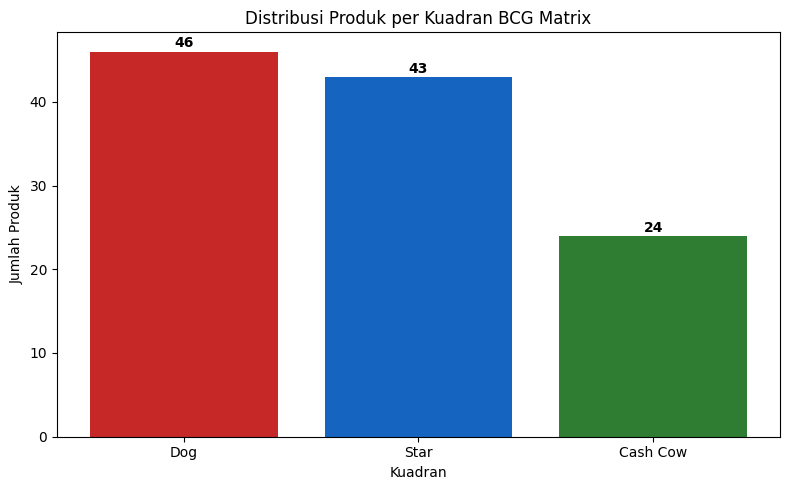

Distribusi:
  Dog: 46 produk
  Star: 43 produk
  Cash Cow: 24 produk


In [6]:
# Visualisasi distribusi kuadran BCG
kuadran_count = bcg_hasil['kuadran'].value_counts()

colors = {'Star': '#1565C0', 'Cash Cow': '#2E7D32',
          'Question Mark': '#F57F17', 'Dog': '#C62828'}
color_list = [colors.get(k, 'gray') for k in kuadran_count.index]

plt.figure(figsize=(8, 5))
bars = plt.bar(kuadran_count.index, kuadran_count.values, color=color_list)
plt.title('Distribusi Produk per Kuadran BCG Matrix')
plt.xlabel('Kuadran')
plt.ylabel('Jumlah Produk')
for bar, val in zip(bars, kuadran_count.values):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
             str(val), ha='center', fontweight='bold')
plt.tight_layout()
plt.show()

print("Distribusi:")
for kuadran, count in kuadran_count.items():
    print(f"  {kuadran}: {count} produk")

In [7]:
# Test Inference Lokal
def prediksi_bcg_lokal(produk_list):
    df_input = pd.DataFrame(produk_list)
    df_input['log_qty'] = np.log1p(df_input['qty_terjual'])
    X = df_input[['margin_pct', 'log_qty']].values
    X_scaled = scaler_bcg.transform(X)
    clusters = kmeans.predict(X_scaled)

    hasil = []
    for i, row in df_input.iterrows():
        cluster_id = str(clusters[i])
        info = cluster_mapping.get(cluster_id, {})
        hasil.append({
            'nama_produk': row['nama_produk'],
            'margin_pct':  row['margin_pct'],
            'qty_terjual': row['qty_terjual'],
            'kuadran':     info.get('kuadran', 'Unknown'),
            'rekomendasi': info.get('rekomendasi', '-')
        })
    return hasil

test_input = [
    {'nama_produk': 'Indomie Goreng', 'margin_pct': 22.9, 'qty_terjual': 850},
    {'nama_produk': 'Beras 10kg',     'margin_pct': 13.1, 'qty_terjual': 120},
    {'nama_produk': 'Sabun Mandi',    'margin_pct': 30.0, 'qty_terjual': 45},
    {'nama_produk': 'Rokok GG',       'margin_pct': 10.0, 'qty_terjual': 30},
]

hasil_lokal = prediksi_bcg_lokal(test_input)
print("Hasil inference lokal:")
for h in hasil_lokal:
    print(f"  {h['nama_produk']:25s} -> {h['kuadran']:15s} | {h['rekomendasi']}")

Hasil inference lokal:
  Indomie Goreng            -> Star            | Pertahankan stok, prioritaskan display dan promosi.
  Beras 10kg                -> Dog             | Pertimbangkan kurangi stok atau hapus dari katalog.
  Sabun Mandi               -> Cash Cow        | Tingkatkan promosi untuk mendorong volume penjualan.
  Rokok GG                  -> Dog             | Pertimbangkan kurangi stok atau hapus dari katalog.


In [8]:
import requests

url = "https://umkm-bersama-production.up.railway.app/api/ai/bcg-matrix"

data = {
    "produk": [
        {"id_produk": "PRD-001", "nama_produk": "Indomie Goreng",
         "harga_jual": 3500, "harga_pokok": 2700, "qty_terjual": 850},
        {"id_produk": "PRD-002", "nama_produk": "Beras 10kg",
         "harga_jual": 130000, "harga_pokok": 113000, "qty_terjual": 120},
        {"id_produk": "PRD-003", "nama_produk": "Sabun Mandi",
         "harga_jual": 5000, "harga_pokok": 3500, "qty_terjual": 45},
    ]
}

r = requests.post(url, json=data)
hasil = r.json()
print(f"Total produk: {hasil['total_produk']}")
print(f"Ringkasan: {hasil['ringkasan']}")
for p in hasil['produk']:
    print(f"  {p['nama_produk']:25s} -> {p['kuadran']}")

Total produk: 3
Ringkasan: {'Star': 1, 'Dog': 1, 'Cash Cow': 1}
  Indomie Goreng            -> Star
  Beras 10kg                -> Dog
  Sabun Mandi               -> Cash Cow
